# 7강. 선형 함수 근사

7강에서는 회귀(regression) 작업을 위한 선형 모델(linear models)의 수식을 다룬다.

구체적으로, 입력 변수 $x$에 적용된 비선형 변환(기저 함수)의 선형 결합으로 목표 변수 $y$를 표현하는 개념을 바탕으로 논의를 진행한다.

## 1. 선형 기저 함수 모델 (Linear Basis Function Models, LBF Models)

입력 $x$와 출력 $y$ 사이의 관계는 $x$의 기저 함수(basis function)를 사용한 선형 결합으로 포착할 수 있다고 가정

**핵심 아이디어:**

$y$를 단순한 선형 함수로 직접 모델링하는 대신(예: $y = w_0 + w_1 x$), 다음과 같이 모델링한다:
$$
y(x) = w_0 \phi_0(x) + w_1 \phi_1(x) + \cdots + w_{M-1}\phi_{M-1}(x).
$$

이 형태에서 기저 함수(basis function) $\phi_j(x)$의 선택을 통해 복잡한 관계를 모델링 할 수 있다.

## 2. LBF 모델에 대한 Motivation

$N$개의 데이터 $\{(x_n, y_n)\}_{n=1}^N$가 있다고 해보자. 우리는 새로운 입력 $x$에 대해 $y$를 예측하는 함수 $y(x)$를 찾고자 한다.

단순 선형 모델은 다음과 같다:
$$
y(x) = w_0 + w_1 x.
$$

그러나 이는 너무 제한적이다. **기저 함수**를 도입하면 다음과 같이 작성할 수 있다:
$$
y(x) = \sum_{j=0}^{M-1} w_j \phi_j(x),
$$
여기서 $\phi_j(x)$는 다항식 항($x^j$)이나 더 복잡한 함수일 수 있다. 


## 3. 선형 회귀 모델

파라미터 벡터 $\boldsymbol{w}$와 기저 함수 벡터 $\boldsymbol{\phi}(x)$를 다음과 같이 정의한다:
$$
\boldsymbol{w} = 
\begin{bmatrix}
w_0 \\
w_1 \\
\vdots \\
w_{M-1}
\end{bmatrix}, \quad
\boldsymbol{\phi}(x) = 
\begin{bmatrix}
\phi_0(x) \\
\phi_1(x) \\
\vdots \\
\phi_{M-1}(x)
\end{bmatrix}.
$$

그러면,
$$
y(x,\boldsymbol{w}) = \boldsymbol{w}^T \boldsymbol{\phi}(x).
$$

이 모델은 $\phi_j(x)$가 $x$에 대해 비선형적이지만, 파라미터 $w_j$에 대해서는 선형적임에 유의 (선형 회귀 모델).


## 4. 기저 함수

기저 함수 $\phi$는 자유롭게 선택 가능하다. 예를 들면:

- **다항식 기저:** $\phi_j(x) = x^j$.
- **Radial Basis Functions (RBF):** $\phi_j(x) = \exp\left(-\frac{(x - \mu_j)^2}{2\sigma^2}\right)$.
- **푸리에 기저:** $\phi_j(x) = \sin(jx)$ 또는 $\cos(jx)$.

기저 함수의 선택은 모델의 유연성과 일반화에 크게 영향을 미칠 수 있다.

**코드 예제:** 입력 데이터를 사용하여 다항식 기저 디자인 행렬을 생성하는 간단한 함수를 만들어보자.

### 참고: $\Phi $ Notation  

각 데이터 포인트에 대해:
$$
y_1 = \boldsymbol{w}^T \boldsymbol{\phi}(x_1)  = \boldsymbol{\phi}^T(x_1)\boldsymbol{w} 
$$
$$
y_2 = \boldsymbol{\phi}^T(x_2)\boldsymbol{w} 
$$
$$
\vdots
$$
$$
y_N = \boldsymbol{\phi}^T(x_N)\boldsymbol{w} 
$$

**행렬-벡터 표현:**

$$
\begin{bmatrix}
y_1 \\
\vdots \\
y_N
\end{bmatrix}
=
\begin{bmatrix}
\boldsymbol{\phi}^T(x_1) \\
\vdots \\
\boldsymbol{\phi}^T(x_N)
\end{bmatrix}
\boldsymbol{w}
,
$$

또는 간단히
$$
\boldsymbol{y} = \Phi \boldsymbol{w} .
$$

In [1]:
import numpy as np

def polynomial_features(x, degree):
    """
    Given a 1D array x and an integer degree, 
    return a design matrix Phi for polynomial basis functions:
    [1, x, x^2, ..., x^degree].
    """
    x = np.asarray(x)
    # np.vander creates a Vandermonde matrix
    # increasing=True : [1, x, x^2, ..., x^degree]
    Phi = np.vander(x, degree+1, increasing=True)
    return Phi

In [2]:
print(polynomial_features([2],2))
print(polynomial_features([1,2,3,4,5],2))

[[1 2 4]]
[[ 1  1  1]
 [ 1  2  4]
 [ 1  3  9]
 [ 1  4 16]
 [ 1  5 25]]


## 5. 예제: 다항식 적합하기

다항식 모델을 합성 데이터에 적합해보자. 데이터 생성 시, 다음 모델을 가정한다:

$$
y = 0.5 + 2x - x^2  + \epsilon, \; \epsilon \sim \mathcal{N}(0, 1^2).
$$

우리는 데이터를 생성하고, 다항식 기저를 사용하여, 최소자승해(least squares solution)를 통해 $\boldsymbol{w}$를 구할 것이다:  
$$
\boldsymbol{w} = ( \Phi^T \Phi )^{-1} \Phi^T \boldsymbol{y},
$$
여기서 $\Phi$는 $N \times M$ 크기의 **디자인 행렬**(design matrix)로, $n$번째 행은 ${\boldsymbol{\phi}}(x_n)^T$이고, $\boldsymbol{y}$는 벡터 $(y_1, y_2, \dots, y_N)^T$이다.

In [3]:
# Generate synthetic data
np.random.seed(1)
N = 50
X = np.linspace(-2, 2, N)
true_w = np.array([0.5, 2.0, -1.0])
y_true = true_w[0] + true_w[1]*X + true_w[2]*(X**2)
noise = np.random.normal(0, 1, size=N)
y = y_true + noise

In [4]:
# Build polynomial design matrix (up to x^2)
Phi = polynomial_features(X, degree=2)

# Solve the normal equations
w_est = np.linalg.inv(Phi.T @ Phi) @ (Phi.T @ y)
print("Estimated parameters:", w_est)

Estimated parameters: [ 0.30818627  2.10168187 -0.88016698]


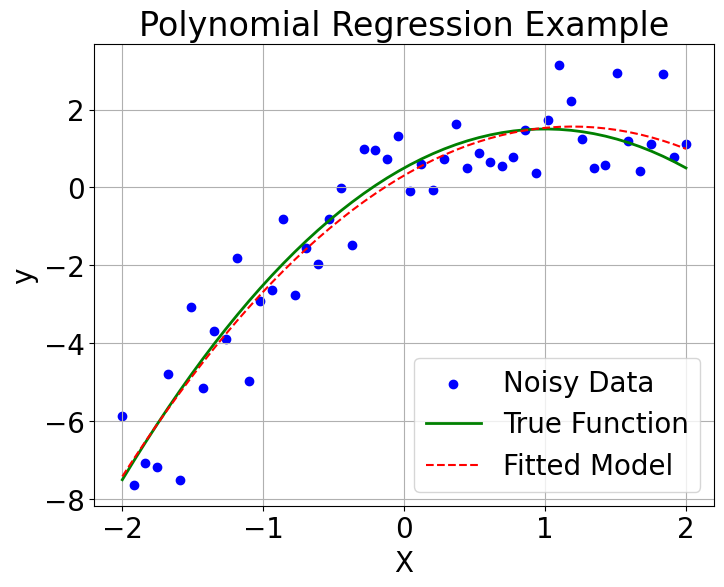

In [5]:
# Predict with the fitted model
y_pred = Phi @ w_est

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})  # 전역 폰트 크기를 20로 설정
plt.figure(figsize=(8,6))
plt.scatter(X, y, label='Noisy Data', color='blue')
plt.plot(X, y_true, label='True Function', color='green', linewidth=2)
plt.plot(X, y_pred, label='Fitted Model', color='red', linestyle='--')
plt.legend()
plt.title("Polynomial Regression Example")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

### 토론:

- 추정된 파라미터 $\boldsymbol{w}_{est}$는 실제 값 $[0.5, 2.0, -1.0]$에 가까워야 한다.

- 데이터가 많을수록, 또 노이즈가 작을수록, 추정치는 실제 값에 가까워져야 한다.

## 6. 선형 회귀 모델의 최대 우도 해석

우리의 선형 모델을 다시 상기해보자:
$$
y(x,\boldsymbol{w}) = \boldsymbol{w}^T\boldsymbol{\phi}(x) = \sum_{j=0}^{M-1}w_j\phi_j(x).
$$

$N$개의 데이터 $\{(x_n, t_n)\}_{n=1}^N$로 구성된 훈련 데이터셋이 주어졌을 때, 우리의 목표는 주어진 데이터를 가장 잘 설명하는 파라미터 $\boldsymbol{w}$를 찾는 것이다. **최소자승법**에서는, 다음의 자승오차합을 손실함수(Loss function, $L$)로 규정, $L$을 최소화하는 $\boldsymbol{w}$를 선택한다:
$$
L(\boldsymbol{w}) = \sum_{n=1}^{N} \bigl(y_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n)\bigr)^2.
$$

이는 잘 알려진 정규방정식(normal equations) 및 닫힌 형태의 해(closed-form solution)로 이어진다 (단, $\Phi^T\Phi$가 가역일 때):
$$
\boldsymbol{w}_{\text{LS}} = (\Phi^T \Phi)^{-1} \Phi^T \boldsymbol{y}.
$$

**증명:**

$$L(\boldsymbol{w}) = \sum_{n=1}^N (y_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n))^2 = (\boldsymbol{y} - \Phi \boldsymbol{w})^T(\boldsymbol{y} - \Phi \boldsymbol{w}). $$

유도과정(벡터 미분):

$$
\begin{aligned}
\frac{\partial L(\boldsymbol{w})}{\partial \boldsymbol{w}} &=\frac{\partial}{\partial \boldsymbol{w}} \left\{ (\boldsymbol{y} - \Phi \boldsymbol{w})^T(\boldsymbol{y} - \Phi \boldsymbol{w})  \right\}\\
&= - 2\Phi^T (\boldsymbol{y} - \Phi \boldsymbol{w})  = \boldsymbol{0}.
\end{aligned}
$$

위 식의 해를 $\boldsymbol{w}^*$로 표기하고 정리하면,
$$
-\Phi^T \boldsymbol{y} + \Phi^T \Phi \boldsymbol{w}^*  = \boldsymbol{0},
$$

$$
(\Phi^T \Phi )\boldsymbol{w}^* = \Phi^T \boldsymbol{y}.
$$

$$
\boldsymbol{w}^* = (\Phi^T \Phi ) ^{-1}\Phi^T \boldsymbol{y}.
$$

### 최소자승법의 최대우도 해석

최소자승해(least squares solution)는 데이터에 대한 **확률적 모델**(정규분포 노이즈) 하에서 $\boldsymbol{w}$의 **최대우도추정치**(MLE)로 해석될 수 있다.

**핵심 아이디어:**

- 관측된 데이터 $t_n$는 모델 $y(x_n,\boldsymbol{w})$에 다음의 독립적인 정규분포 잡음이 더해져 생성된다고 가정한다:
  $$
  t_n = \boldsymbol{w}^T\boldsymbol{\phi}(x_n) + \epsilon_n,
  \quad \text{where } \epsilon_n \sim \text{iid }\mathcal{N}(0, \sigma^2).
  $$
  
- 파라미터 $\boldsymbol{w}$와 입력 $X = (x_1,\dots,x_N)$이 주어졌을 때, 데이터 $\boldsymbol{t} = (t_1, \dots, t_N)$를 관찰할 확률(우도)는 다음과 같다:
  $$
  p(\boldsymbol{t}|\boldsymbol{w}, X) = \prod_{n=1}^{N} \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{\bigl(t_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n)\bigr)^2}{2\sigma^2}\right).
  $$

- 이 우도의 로그를 취한 **로그우도**는 다음과 같이 표현된다:
  $$
  \ln p(\boldsymbol{t}|\boldsymbol{w}, X) = -\frac{N}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{n=1}^{N}\bigl(t_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n)\bigr)^2.
  $$

- 이 로그우도를 $\boldsymbol{w}$에 대해 최대화하는 것은 자승오차합을 **최소화**하는 것과 동등하다:
  $$
  \sum_{n=1}^{N}\bigl(t_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n)\bigr)^2.
  $$

따라서, 정규분포 잡음 가정하에 자승오차를 최소화하는 파라미터 벡터 $\boldsymbol{w}$는 관찰된 데이터의 우도를 최대화하는 파라미터 벡터와 정확히 동일하다. 즉, 최소자승해는 선형 모델의 정규분포 잡음 하에서 최대우도해와 동일하다.

#### $\Phi $ Notation  

각 데이터 포인트에 대해:
$$
t_1 = \boldsymbol{w}^T \boldsymbol{\phi}(x_1) + \epsilon_1 = \boldsymbol{\phi}^T(x_1)\boldsymbol{w} + \epsilon_1
$$
$$
t_2 = \boldsymbol{\phi}^T(x_2)\boldsymbol{w} + \epsilon_2
$$
$$
\vdots
$$
$$
t_N = \boldsymbol{\phi}^T(x_N)\boldsymbol{w} + \epsilon_N
$$

**행렬-벡터 표현:**

$$
\begin{bmatrix}
t_1 \\
\vdots \\
t_N
\end{bmatrix}
=
\begin{bmatrix}
\boldsymbol{\phi}^T(x_1) \\
\vdots \\
\boldsymbol{\phi}^T(x_N)
\end{bmatrix}
\boldsymbol{w}
+
\begin{bmatrix}
\epsilon_1 \\
\vdots \\
\epsilon_N
\end{bmatrix},
$$

또는 간단히
$$
\boldsymbol{t} = \Phi \boldsymbol{w} + \boldsymbol{\epsilon}.
$$

---

### 왜 중요한가?

1. **확률적 해석:** 결정론적인 최소자승해를 확률적 틀로 연결하여, 그 통계적 성질에 대한 통찰을 제공.

2. **다른 손실함수로 확장:** 가정된 잡음 모델을 바꾸면, 대응되는 최대우도해가 다른 손실함수로 이어진다. 예를 들어, 라플라스 분포의 잡음을 가정하면 절대편차(L1 손실)를 최소화하게 된다.

3. **신뢰구간 및 베이즈 방법:** 확률적 모델을 기반으로 신뢰구간, 예측구간을 도출하거나 베이즈 접근법(예: $\boldsymbol{w}$에 사전분포를 부여)으로 자연스럽게 확장할 수 있다.

**요약:** 최소자승해는 단순한 (결정론적인) 수학적 산물이 아니라, 선형 모델과 정규분포 잡음이라는 널리 사용되는 확률적 가정 하에서 자연스럽게 나타나는 최우추정치이다.

## 7. 정규화된 최소자승법 (Regularized Least-Squares)

훈련 데이터 $D = \{(x_n, t_n)\}_{n=1}^N$가 주어졌을 때, 최소자승법의 성능 지수(Performance Index, PI)를 다음과 같이 정의할 수 있다.

**최소자승법의 성능 지수:**
$$
\varepsilon_{\text{LS}} = \frac{1}{2}\sum_{n=1}^N (t_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n))^2 .
$$

여기서, 파라미터 값들($\boldsymbol{w}$ 벡터의 원소 값들)이 함부로 큰 값이 나오지 않도록 정규화할(Regularization) 수 있는데 이 때 정의할 성능 지수는 다음과 같다.

**정규화된 최소자승법의 성능 지수:**
$$
\varepsilon_{\text{Reg.LS}} = \varepsilon_{LS} + \lambda \varepsilon_w(\boldsymbol{w}).
$$

여기서, $\lambda$는 정규화의 강도를 조절하는 하이퍼파라미터로 이 값이 너무 크면 정규화 효과가 지나치게 강해져 파라미터 값들이 거의 0에 가까워지고, 너무 작으면 정규화 효과가 약해져 파라미터 값이 자유롭게 커질 수 있다. $\varepsilon_w$를 어떻게 정의하는냐에 따라 여러 정규화 방법들이 있다. 본 강의에서는 L2 정규화 방법을 고려한다.

### L2 정규화 방법

L2 정규화 방법에서는 $\varepsilon_w$를 다음과 같이 정의한다:

$$
\varepsilon_w(\boldsymbol{w}) = \frac{1}{2}\boldsymbol{w}^T \boldsymbol{w} = \frac{1}{2}\|\boldsymbol{w}\|_2^2 .
$$

따라서,
$$
\varepsilon_{\text{Reg.LS}} = \frac{1}{2}\|\boldsymbol{t} - \Phi \boldsymbol{w}\|^2 + \frac{\lambda}{2}\|\boldsymbol{w}\|_2^2 .
$$

여기서, $\|\boldsymbol{t} - \Phi \boldsymbol{w}\|^2 = (\boldsymbol{t} - \Phi \boldsymbol{w})^T(\boldsymbol{t} - \Phi \boldsymbol{w}) = \sum_{n=1}^N (t_n - \boldsymbol{w}^T\boldsymbol{\phi}(x_n))^2$ 이다.

**최적화:**

다음의 조건을 만족하도록 최적화한다.
$$
\frac{\partial \varepsilon_{\text{Reg.LS}}}{\partial \boldsymbol{w}} = \boldsymbol{0}
$$

유도과정(벡터 미분):

$$
\begin{aligned}
\frac{\partial \varepsilon_{\text{Reg.LS}}}{\partial \boldsymbol{w}} &=\frac{\partial}{\partial \boldsymbol{w}} \left\{ \frac{1}{2} (\boldsymbol{t} - \Phi \boldsymbol{w})^T(\boldsymbol{t} - \Phi \boldsymbol{w}) +\frac{\lambda}{2}\boldsymbol{w}^T \boldsymbol{w} \right\}\\
&= - \Phi^T (\boldsymbol{t} - \Phi \boldsymbol{w}) +\lambda \boldsymbol{w} = \boldsymbol{0}.
\end{aligned}
$$

위 식의 해를 $\boldsymbol{w}^*$로 표기하고 정리하면,
$$
-\Phi^T \boldsymbol{t} + \Phi^T \Phi \boldsymbol{w}^* + \lambda \boldsymbol{w}^* = \boldsymbol{0},
$$

$$
(\Phi^T \Phi + \lambda I)\boldsymbol{w}^* = \Phi^T \boldsymbol{t}.
$$

따라서, L2 정규화된 최소자승해는
$$
\boldsymbol{w}^* = (\Phi^T \Phi + \lambda I)^{-1}\Phi^T \boldsymbol{t}.
$$

## 8. 베이지안 선형 회귀 (Bayesian Linear Regression)

---
### Notation 정리
**근사함수(Approximator):**
$$
y(x,\boldsymbol{w}) = \boldsymbol{w}^T \boldsymbol{\phi}(x) = w_0 + w_1 \phi_1(x) + \cdots + w_{M-1}\phi_{M-1}(x)
$$

**사전분포 (Prior):**
$$
\boldsymbol{w} \sim \mathcal{N}(\boldsymbol{m}_0, S_0)
$$

**IID training data:**
$$
D = \{(x_n, t_n)\}_{n=1}^N
$$

**우도 (Likelihood):**
$$
P(D \mid \boldsymbol{w})
$$

**사후분포 (Posterior):**
$$
P(\boldsymbol{w} \mid D) = \frac{P(\boldsymbol{w},D)}{P(D)} \propto P(D \mid \boldsymbol{w})P(\boldsymbol{w})
$$

**Note:** 사후 분포는 우도와 사전분포의 곱에 비례한다.
$$
\text{posterior} \propto \text{likelihood} \times \text{prior}
$$

---

### Model:
$$
t = \boldsymbol{w}^T \boldsymbol{\phi}(x) + \epsilon, \quad \text{where } \epsilon \sim \text{iid } \mathcal{N}(0,\beta^{-1}).
$$
여기서, $\beta$는 precision으로 분산의 역수를 의미하고, 우선은 알려진 상수 값이라고 가정한다.

### IID Training Data:  
$$
D = \{(x_n, t_n)\}_{n=1}^N
$$

각 데이터 포인트에 대해:
$$
t_1 = \boldsymbol{w}^T \boldsymbol{\phi}(x_1) + \epsilon_1 = \boldsymbol{\phi}^T(x_1)\boldsymbol{w} + \epsilon_1
$$
$$
t_2 = \boldsymbol{\phi}^T(x_2)\boldsymbol{w} + \epsilon_2
$$
$$
\vdots
$$
$$
t_N = \boldsymbol{\phi}^T(x_N)\boldsymbol{w} + \epsilon_N
$$

**행렬-벡터 표현:**

$$
\begin{bmatrix}
t_1 \\
\vdots \\
t_N
\end{bmatrix}
=
\begin{bmatrix}
\boldsymbol{\phi}^T(x_1) \\
\vdots \\
\boldsymbol{\phi}^T(x_N)
\end{bmatrix}
\boldsymbol{w}
+
\begin{bmatrix}
\epsilon_1 \\
\vdots \\
\epsilon_N
\end{bmatrix},
$$

또는 간단히
$$
\boldsymbol{t} = \Phi \boldsymbol{w} + \boldsymbol{\epsilon}.
$$

---
### 복습: 다변량 정규분포 (Multivariate Normal Distribution)
$ \boldsymbol{X} \sim \mathcal{N}(\boldsymbol{\mu}, \Sigma) $에서:
$$
f_\boldsymbol{X}(\boldsymbol{x}) = \frac{1}{\sqrt{|2\pi \Sigma|}}\exp\left(-\frac{1}{2}(\boldsymbol{x} - \boldsymbol{\mu})^T\Sigma^{-1}(\boldsymbol{x} - \boldsymbol{\mu})\right).
$$

---

### 사전분포 (Prior):
$$
\boldsymbol{w} \sim \mathcal{N}(\boldsymbol{m}_0, S_0),
$$
여기서, $\boldsymbol{m}_0 = \boldsymbol{0}$, $S_0 = \alpha^{-1} I$로 가정하면 ($\alpha$는 precision),
$$
P(\boldsymbol{w}) \propto \exp\left(-\frac{\alpha}{2}\boldsymbol{w} ^T \boldsymbol{w} \right).
$$

### 우도 (Likelihood):
$$
\boldsymbol{t} \sim \mathcal{N}(\Phi \boldsymbol{w}, \beta^{-1}I)
$$

$$
P(D|\boldsymbol{w}) \propto \exp\left(-\frac{\beta}{2}(\boldsymbol{t} - \Phi \boldsymbol{w})^T (\boldsymbol{t} - \Phi \boldsymbol{w}) \right)
$$

### 사후분포 (Posterior):
$$
P(\boldsymbol{w}|D) = \frac{P(\boldsymbol{w},D)}{P(D)} \propto P(D|\boldsymbol{w})P(\boldsymbol{w})
$$

사후분포는 우도와 사전분포의 곱에 비례하므로,
$$
P(\boldsymbol{w}|D)\propto \exp\left(-\frac{\beta}{2}(\boldsymbol{t} - \Phi \boldsymbol{w})^T (\boldsymbol{t} - \Phi \boldsymbol{w}) \right)  \exp\left(-\frac{\alpha}{2}\boldsymbol{w} ^T \boldsymbol{w} \right).
$$


---
### 복습: 다변량 정규분포 (Multivariate Normal Distribution)
$ \boldsymbol{X} \sim \mathcal{N}(\boldsymbol{\mu}, \Sigma) $에서:
$$
f_\boldsymbol{X}(\boldsymbol{x}) = \frac{1}{\sqrt{|2\pi \Sigma|}}\exp\left(-\frac{1}{2}(\boldsymbol{x} - \boldsymbol{\mu})^T\Sigma^{-1}(\boldsymbol{x} - \boldsymbol{\mu})\right).
$$

### 2차 항과 1차 항:
$$
-\frac{1}{2}(\boldsymbol{x} - \boldsymbol{\mu})^T \Sigma^{-1}(\boldsymbol{x} - \boldsymbol{\mu}) = -\frac{1}{2}\boldsymbol{x}^T\Sigma^{-1}\boldsymbol{x} + \boldsymbol{x}^T\Sigma^{-1}\boldsymbol{\mu} + \text{const.}
$$

---

#### $\boldsymbol{w}$에 대한 2차 항:
$$
-\frac{1}{2} \boldsymbol{w}^T (\beta \Phi^T \Phi + \alpha I) \boldsymbol{w}
$$
따라서:
$$
S_N^{-1} = \beta \Phi^T \Phi + \alpha I
$$

#### $\boldsymbol{w}$에 대한 1차 항:
$$
\beta \boldsymbol{w}^T \Phi^T \boldsymbol{t} 
$$
따라서:
$$
\boldsymbol{m}_N =  \beta S_N\Phi^T \boldsymbol{t} 
$$

### 사후분포 최종 계산 결과:

$$
 P(\boldsymbol{w}|D) \; : \quad \boldsymbol{w} \sim \mathcal{N}( \boldsymbol{m}_N, S_N),
$$
여기서,
$$
\boldsymbol{m}_N = \left(  \Phi^T \Phi + \dfrac{\alpha}{\beta} I \right)^{-1}\Phi^T \boldsymbol{t}  , \quad S_N = \left( \ \beta \Phi^T \Phi +\alpha I \right)^{-1}.
$$

### 사후분포 결과에 대한 해석 

1. 만약 $\alpha = 0$이면:
$$
\boldsymbol{m}_N = \left(\Phi^T \Phi\right)^{-1} \Phi^T \boldsymbol{t} = \boldsymbol{w}_{\text{LS}}
$$

2. 만약 $\lambda = \dfrac{\alpha}{\beta}$라면:
$$
\boldsymbol{m}_N = \boldsymbol{w}_{\text{Reg.LS}}
$$

$$
\boldsymbol{m}_N = \left(  \Phi^T \Phi + \dfrac{\alpha}{\beta} I \right)^{-1}\Phi^T \boldsymbol{t}
$$

$$
S_N = \left(\beta \Phi^T \Phi + \alpha I   \right)^{-1}
$$

### 예측분포 (Predictive Distribution)

훈련 데이터가 $ D = \{(x_n,t_n)\}_{n=1}^N $일 때,
$$
\boldsymbol{t} = \begin{bmatrix} t_1 \\ \vdots \\ t_N \end{bmatrix}
$$

**사후분포:** 
$$ P(\boldsymbol{w}|D) = \mathcal{N}(\boldsymbol{w} | \boldsymbol{m}_N, S_N). $$

**예측분포:**

예측분포는 새로운 입력 $ x^* $가 주어졌을 때 사후분포를 이용하여 출력 $ t^* $를 예측하는 분포로 다음과 같다:
$$
P(t^* | x^*, D) = \int P(t^* | x^*, \boldsymbol{w}) P(\boldsymbol{w} | D) d\boldsymbol{w}.
$$

여기서,
$$
P(t^* | x^*, \boldsymbol{w}) =  \mathcal{N}\left(t^* \big| \boldsymbol{\phi}(x^* ) ^T \boldsymbol{w} , \beta^{-1}\right).
$$

---

### 참고: 다변량 정규분포의 성질 (Bishop, p93)

다변량 정규분포 $\boldsymbol{x}$와 조건부분포 $\boldsymbol{y|x}$가 다음과 같이 주어질 때, 
$$
\begin{align}
p(\boldsymbol{x}) &= \mathcal{N} \left( \boldsymbol{x} | \boldsymbol{\mu},\Lambda^{-1} \right) \\
p(\boldsymbol{y|x}) &= \mathcal{N} \left( \boldsymbol{y} | A\boldsymbol{x}+\boldsymbol{b}, L^{-1} \right)
\end{align}
$$
$\boldsymbol{y}$의 주변분포와 조건부분포 $\boldsymbol{x|y}$는 다음과 같다:
$$
\begin{align}
p(\boldsymbol{y}) &= \mathcal{N} \left( \boldsymbol{y} | A\boldsymbol{\mu}+b,L^{-1}+A \Lambda^{-1} A^T \right) \\
p(\boldsymbol{x|y}) &= \mathcal{N} \left( \boldsymbol{x} | \Sigma \left\{ A^T L(\boldsymbol{y}-\boldsymbol{b})+\Lambda \boldsymbol{\mu} \right\} , \Sigma \right)
\end{align}
$$
여기서,
$$
\Sigma = (\Lambda + A^T L A )^{-1}.
$$

---

### 위 p93의 정리(theorem)에 의하면:

다음의 정규분포들이 주어질 때,
$$ 
\begin{align}
P(\boldsymbol{w}|D) &= \mathcal{N}\left(\boldsymbol{w} | \;\boldsymbol{m}_N, \;S_N\right) \\
P(t^* | x^*, \boldsymbol{w}) &=  \mathcal{N} \left(t^* |\; \boldsymbol{\phi}(x^* ) ^T \boldsymbol{w},\; \beta^{-1}\right)
\end{align}
$$

$t^*$의 주변분포는 다음과 같다:

$$
\begin{align}
P(t^*|x^* , D) &= \mathcal{N}\left(t^* | \;\boldsymbol{\phi}(x^*)^T \boldsymbol{m}_N, \;\beta^{-1} + \boldsymbol{\phi}(x^*)^T S_N \boldsymbol{\phi}(x^*) \right),\\
&= \mathcal{N}\left(t^* |\; \boldsymbol{m}_N^T \boldsymbol{\phi}(x^*), \;\sigma_N^2(x^*) \right).
\end{align}
$$


### 참고: $\alpha$와 $\beta$를 어떻게 구하는가?

#### 통계학 style:

$\alpha$는 사전분포의 모수이므로 연구자가 지정한다. 예를 들어, L2 정규화 강도를 표현하는 값으로, $\alpha$값이 클수록 파라미터 $\boldsymbol{w}$는 $\boldsymbol{0}$에 가까워짐.

$\beta$는 데이터로부터 최대우도 추정(MLE)을 사용하여 계산한다. 예를 들어,
$$
\beta = \frac{N}{\|\boldsymbol{t} - \Phi \boldsymbol{w}_{\text{LS}}\|^2}.
$$

#### 머신러닝 style:

$\alpha$와 $\beta$를 하이퍼파라미터로 취급하고, 모델 증거(Model Evidence = marginal likelihood) $P(D|\;\alpha,\beta)$를 최대화하는 값으로 선택한다. 모델 증거는 다음과 같이 정의된다.

$$
P(D|\;\alpha,\beta) = \int P(D|\;\boldsymbol{w},\beta)P(\boldsymbol{w}|\;\alpha)d\boldsymbol{w}.
$$

이에 관한 자세한 내용은 참고교재 **Bishop, 3장**을 참고할 것.

## 9. 예제(위 코드에 이어서 진행): 베이지안 선형 회귀를 이용하여 신뢰구간 구하기

In [6]:
# t = y(x,w) + epsilon
t = y_true + noise

# 베이지안 선형 회귀 하이퍼파라미터 설정
alpha = 1.0  # 사전분포의 정밀도
beta = 1.0   # 관측 노이즈의 정밀도

# 사전분포 (prior dist): mean = 0벡터, precision = alpha*I
prior_mean = np.zeros(Phi.shape[1])
prior_precision = alpha * np.eye(Phi.shape[1])

# Likelihood: precision = beta
# 사후분포 (posterior dist): combine prior and likelihood
posterior_precision = prior_precision + beta * Phi.T @ Phi
posterior_covariance = np.linalg.inv(posterior_precision)
posterior_mean = posterior_covariance @ (beta * Phi.T @ t)

# 예측분포 (predictive dist) 계산
def predict(Phi_new, posterior_mean, posterior_covariance, beta):
    """
    Compute the predictive mean and variance for new data using
    the posterior distribution.
    """
    mean = Phi_new @ posterior_mean
    variance = 1 / beta + np.diag(Phi_new @ posterior_covariance @ Phi_new.T)
    return mean, variance

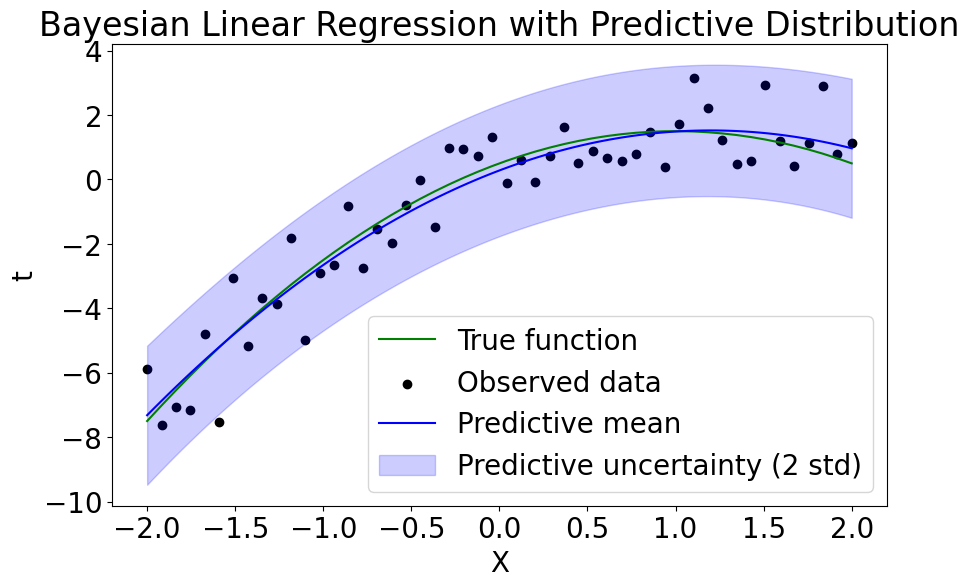

In [7]:
# New data points for prediction
X_new = np.linspace(-2, 2, 100)
Phi_new = polynomial_features(X_new, degree=2)

# Predictive distribution
predictive_mean, predictive_variance = predict(Phi_new, posterior_mean, posterior_covariance, beta)

# Plot true curve, observed data, and predictive distribution
plt.figure(figsize=(10, 6))
plt.plot(X, y_true, label="True function", color="green")
plt.scatter(X, t, label="Observed data", color="black")
plt.plot(X_new, predictive_mean, label="Predictive mean", color="blue")
plt.fill_between(
    X_new,
    predictive_mean - 2 * np.sqrt(predictive_variance),
    predictive_mean + 2 * np.sqrt(predictive_variance),
    color="blue",
    alpha=0.2,
    label="Predictive uncertainty (2 std)"
)
plt.legend()
plt.xlabel("X")
plt.ylabel("t")
plt.title("Bayesian Linear Regression with Predictive Distribution")
plt.show()

## 10. 요약

이번 7강에서는 회귀를 위한 선형 모델의 개념을 소개하고, 모델의 기하학적 및 확률적 해석을 강조하였다:

- **선형 파라미터화**: 출력 변수는 입력 변수에 적용된 고정된 비선형 변환(기저 함수)의 선형 결합으로 표현되었다. 이를 통해 $ x $에서 $ y $로의 매핑은 유연하고 비선형적일 수 있지만, 모델은 파라미터 $ \boldsymbol{w} $에 대해 여전히 선형적이라는 점을 유지했다.

- **일반 최소자승법(OLS) 추정**: 파라미터 추정은 일반 최소자승법(Ordinary Least Squares, OLS)을 통해 수행되며, 이는 닫힌 형태의 해(normal equations)를 제공한다. 이를 통해 최적의 파라미터를 찾는 간단한 계산 접근법을 제공하였다.

- **가우시안 가정 하 최대우도추정과의 동등성**: 관측된 데이터가 선형 모델과 정규분포 잡음에 의해 생성된다고 가정하면, OLS 해법은 정확히 최대우도(Maximum Likelihood, ML)법과 동일하다. 이 동등성은 OLS에 대한 강력한 확률적 기반을 제공하며, 자승오차를 최소화하는 이유에 대한 심층적 이해를 제공하고, 베이즈 방법 및 통계적 추론으로 자연스럽게 확장할 수 있도록 한다.

- **정규화된 최소자승법**:
정규화된 최소자승법(Regularized Least-Squares)은 과적합을 방지하기 위해 손실함수에 패널티 항을 추가하는 방식으로, 이는 베이지안 선형 회귀에서 사전분포를 통해 파라미터를 제어하는 접근법과 밀접하게 연결된다.

- **베이즈 접근법과의 연결**:
최소자승법의 확률적 해석을 통해 사전분포(prior)와 결합하여 베이지안 선형 회귀로 확장할 수 있으며, 이를 통해 모델의 불확실성을 정량화하고 예측구간을 제시할 수 있다.